## Productivity & Behavioral Analysis Using Python

### Objective:
#### Analyse how behavioural, lifestyle, and demographic factors impact productivity, stress, burnout, and job satisfaction.
 

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Load Dataset

In [2]:
df = pd.read_csv('social_media_vs_productivity.csv')
df.head(10)

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060
5,38,Male,Finance,1.512568,Twitter,50,6.429312,NaN,4.081026,5.0,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728
6,56,Female,Unemployed,4.381070,TikTok,60,3.902309,6.420989,5.976408,7.0,7.549849,2.252624,4,False,False,4,20,24.084905,5.501373
7,36,Female,Education,4.089168,Twitter,49,6.560467,2.681830,2.446927,4.0,6.325507,0.747998,2,False,False,4,29,8.419648,3.444376
8,40,Female,Education,4.097401,Instagram,57,5.839590,3.219022,3.004240,4.0,NaN,0.000000,10,False,True,2,10,0.000000,1.960131
9,28,Other,IT,7.595577,Twitter,64,5.888936,NaN,NaN,3.0,6.761952,1.449841,10,False,False,1,18,6.959377,6.808102


#### Data Understanding

In [3]:
print(df.shape)

(30000, 19)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

In [5]:
print(df.isnull().sum())

age                                  0
gender                               0
job_type                             0
daily_social_media_time           2765
social_platform_preference           0
number_of_notifications              0
work_hours_per_day                   0
perceived_productivity_score      1614
actual_productivity_score         2365
stress_level                      1904
sleep_hours                       2598
screen_time_before_sleep          2211
breaks_during_work                   0
uses_focus_apps                      0
has_digital_wellbeing_enabled        0
coffee_consumption_per_day           0
days_feeling_burnout_per_month       0
weekly_offline_hours                 0
job_satisfaction_score            2730
dtype: int64


#### Data Claeaning

In [6]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

In [7]:
for col in numeric_cols:
    df[col].fillna(df[col].mean())

print(df.isnull().sum())

age                                  0
gender                               0
job_type                             0
daily_social_media_time           2765
social_platform_preference           0
number_of_notifications              0
work_hours_per_day                   0
perceived_productivity_score      1614
actual_productivity_score         2365
stress_level                      1904
sleep_hours                       2598
screen_time_before_sleep          2211
breaks_during_work                   0
uses_focus_apps                      0
has_digital_wellbeing_enabled        0
coffee_consumption_per_day           0
days_feeling_burnout_per_month       0
weekly_offline_hours                 0
job_satisfaction_score            2730
dtype: int64


#### Feature Engineering

In [8]:
df['is_low_sleep'] = df['sleep_hours'] < 6

In [9]:
df['high_screen_time'] = df['daily_social_media_time'] > 4

In [10]:
df['high_stress'] = df['stress_level'] > 6

In [11]:
df['burnout_risk'] = (
    (df['stress_level'] > 6) &
    (df['sleep_hours'] < 6) &
    (df['work_hours_per_day'] > 8)
)

#### Analysis Functions

In [12]:
def analyze_low_productivity(df):
    low_prod = df[df['actual_productivity_score'] < 5]
    return low_prod[['sleep_hours', 'stress_level', 'daily_social_media_time']].mean()

In [13]:
def analyze_burnout(df):
    burnout = df[df['burnout_risk'] == True]
    return burnout[['work_hours_per_day', 'stress_level', 'sleep_hours']].mean()

In [14]:
def analyze_focus_apps(df):
    return df.groupby('uses_focus_apps')['actual_productivity_score'].mean()

#### Run Analysis

In [15]:
print("Low Productivity Analysis:\n",analyze_low_productivity(df))

Low Productivity Analysis:
 sleep_hours                6.510771
stress_level               5.512327
daily_social_media_time    3.132462
dtype: float64


In [16]:
print("Burnout Analysis:\n",analyze_burnout(df))

Burnout Analysis:
 work_hours_per_day    9.306655
stress_level          8.453072
sleep_hours           4.992769
dtype: float64


In [17]:
print("Focus App Impact:\n",analyze_focus_apps(df))

Focus App Impact:
 uses_focus_apps
False    4.953069
True     4.948872
Name: actual_productivity_score, dtype: float64


#### Correlation Analysis

In [18]:
def productivity_factors(df):
    return df[
        [
            'actual_productivity_score',
            'sleep_hours',
            'stress_level',
            'work_hours_per_day',
            'breaks_during_work',
            'job_satisfaction_score'
        ]
    ].corr()['actual_productivity_score'].sort_values(ascending=False)

In [19]:
print("Productivity Factors:\n",productivity_factors(df))

Productivity Factors:
 actual_productivity_score    1.000000
job_satisfaction_score       0.882965
stress_level                 0.001339
work_hours_per_day          -0.000113
breaks_during_work          -0.004203
sleep_hours                 -0.007868
Name: actual_productivity_score, dtype: float64


#### Demographic Analysis

In [20]:
# Job Type
df.groupby('job_type')['job_satisfaction_score'].mean().sort_values()

job_type
Student       4.931356
Unemployed    4.945052
Education     4.945458
Finance       4.954351
Health        4.968100
IT            5.044602
Name: job_satisfaction_score, dtype: float64

In [21]:
# Gender
df.groupby('gender')['job_satisfaction_score'].mean()

gender
Female    4.961497
Male      4.978728
Other     4.839207
Name: job_satisfaction_score, dtype: float64

In [22]:
# Age Group
df['age_group'] = pd.cut(df['age'], bins=[0,30,45,60,80], labels=['Young','Mid','Senior','Older'])

df.groupby('age_group', observed=True)['job_satisfaction_score'].mean()

age_group
Young     4.911012
Mid       4.986453
Senior    4.962142
Older     5.044025
Name: job_satisfaction_score, dtype: float64

#### Visualization

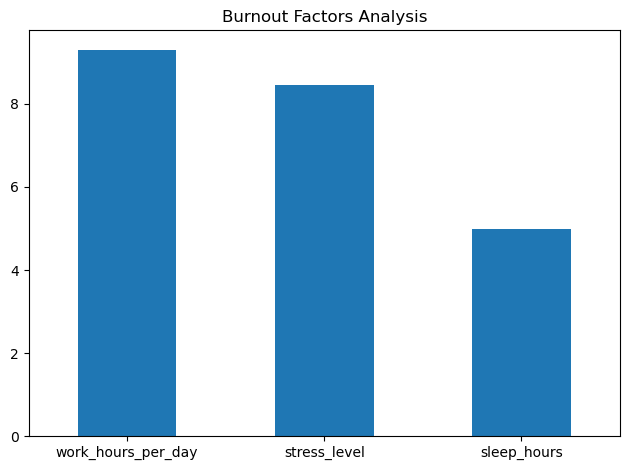

In [23]:
# Burnout Factors Analysis Plot

burnout = df[df['burnout_risk'] == True]

burnout[['work_hours_per_day', 'stress_level', 'sleep_hours']].mean().plot(kind='bar')
plt.title("Burnout Factors Analysis")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

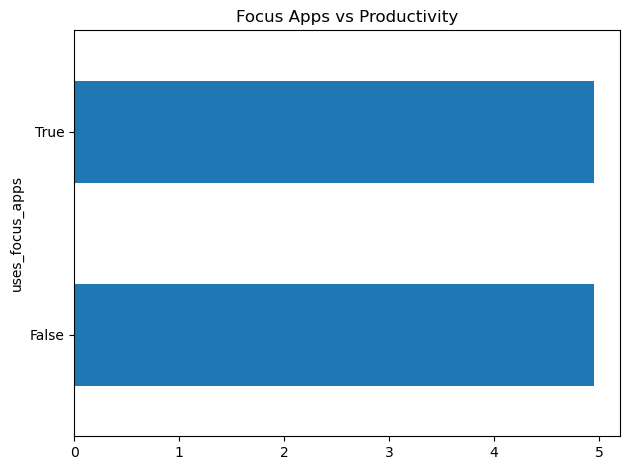

In [24]:
# Focus Apps vs Productivity

df.groupby('uses_focus_apps')['actual_productivity_score'].mean().plot(kind='barh')
plt.title("Focus Apps vs Productivity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Imputation Method Comparison

#### Step 1 — Reload original data

In [25]:
df_original = pd.read_csv("social_media_vs_productivity.csv")

#### Step 2 — Create 3 versions

In [26]:
df_mean = df_original.copy()
df_median = df_original.copy()
df_drop = df_original.dropna()

#### Step 3 — Applied Mean

In [27]:
numeric_cols = df_mean.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())

#### Step 4 — Applied Median

In [28]:
for col in numeric_cols:
    df_median[col] = df_median[col].fillna(df_median[col].median())

#### Step 5 — dropped null records

In [29]:
df_drop = df_original.dropna()

#### Step 6 — Compare

In [30]:
mean_corr = df_mean[['actual_productivity_score', 'job_satisfaction_score']].corr().iloc[0,1]
median_corr = df_median[['actual_productivity_score', 'job_satisfaction_score']].corr().iloc[0,1]
drop_corr = df_drop[['actual_productivity_score', 'job_satisfaction_score']].corr().iloc[0,1]


print("Mean:", mean_corr)
print("Median:", median_corr)
print("Drop NA:", drop_corr)

Mean: 0.8092914126047985
Median: 0.8092888230516423
Drop NA: 0.8835264798931295


### Imputation Comparison Insight

Mean and median imputation produced nearly identical correlation results, indicating that the dataset is not heavily skewed. However, dropping missing values increased the correlation significantly, suggesting that incomplete records may contain noise or variability. While dropping nulls provides a stronger relationship, it reduces dataset size and may introduce bias. Therefore, mean imputation was retained for balanced analysis.

#### Export Cleaned Dataset

In [31]:
# Exporting cleaned and processed data for dashboard creation

df.to_csv("cleaned_productivity_data.csv", index=False)

### Key Insights
- Job satisfaction strongly impacts productivity
- Burnout is driven by stress, low sleep, and long work hours
- Focus apps show minimal impact on productivity
- Demographics show slight variation in job satisfaction
- Job satisfaction is not strongly linearly dependent on behavioral factors

### Final Conclusion

This analysis highlights that productivity is primarily influenced by job satisfaction rather than direct behavioural factors like sleep or screen time. While burnout is driven by stress, low sleep, and long working hours, job satisfaction itself is shaped by more complex and less directly measurable factors. This indicates that improving workplace experience may have a greater impact on productivity than focusing only on behavioral habits.